#### **Selección de Entorno y Complementos**

In [ ]:
# CONFIGURACIÓN DE ENTORNO

# Si no cuenta con Google Drive instalado, cambie a True SOLO si desea ejecutar este notebook en Google Colab y quiere usar la conexión a Drive.

# En caso seleccione True, deberá configurar el Kernel para trabajar con Colab y Drive antes de ejecutar esta celda, además deberá especificar 
# el nombre y ruta de su archivo en la celda "Carga de Imagen"

# Si estás en VS Code con kernel local, mantenga en False.

COLAB = False

In [ ]:
# INSTALACIÓN DE DEPENDENCIAS

# Tesseract como motor OCR debe instalarse a nivel de sistema operativo.

if COLAB:
    !apt-get install tesseract-ocr tesseract-ocr-spa -y
else:
    #   Tesseract debe instalarse manualmente según tu SO:
    #   Windows -> https://github.com/UB-Mannheim/tesseract/wiki
    #   Mac     -> brew install tesseract tesseract-lang
    #   Linux   -> sudo apt-get install tesseract-ocr tesseract-ocr-spa
    print("Modo local: asegúrate de tener Tesseract instalado en tu sistema.")

# Librerías de Python
!pip install pytesseract opencv-python numpy matplotlib -q

Modo local: asegúrate de tener Tesseract instalado en tu sistema.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import urllib.request
import pytesseract


# CONFIGURACIÓN AUTOMÁTICA DE TESSERACT Y ESPAÑOL

# 1. Localizar el ejecutable de Tesseract en el sistema
ruta_tesseract = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
if not os.path.exists(ruta_tesseract):
    ruta_usuario = os.path.expanduser(r"~\AppData\Local\Programs\Tesseract-OCR\tesseract.exe")
    if os.path.exists(ruta_usuario):
        ruta_tesseract = ruta_usuario

if os.path.exists(ruta_tesseract):
    pytesseract.pytesseract.tesseract_cmd = ruta_tesseract
    print(f"Tesseract encontrado en: {ruta_tesseract}")
else:
    print("Tesseract no está instalado en el sistema.")

# 2. Configurar una carpeta tessdata local en el perfil del usuario (evita permisos de administrador)
carpeta_tessdata_usuario = os.path.expanduser(r"~\AppData\Local\Tesseract-OCR\tessdata")
os.makedirs(carpeta_tessdata_usuario, exist_ok=True)

ruta_spa = os.path.join(carpeta_tessdata_usuario, "spa.traineddata")

# 3. Descargar automáticamente el archivo de idioma español si no existe
if not os.path.exists(ruta_spa):
    print("Descargando el paquete de idioma español (spa.traineddata) desde GitHub...")
    url_spa = "https://github.com/tesseract-ocr/tessdata/raw/main/spa.traineddata"
    try:
        urllib.request.urlretrieve(url_spa, ruta_spa)
        print("¡Archivo 'spa.traineddata' descargado y configurado con éxito!")
    except Exception as e:
        print(f"No se pudo descargar el idioma automáticamente: {e}")
else:
    print("¡El paquete de idioma español ya está listo en el sistema!")

# 4. Establecer la variable de entorno para que Tesseract reconozca la ruta del idioma
os.environ["TESSDATA_PREFIX"] = carpeta_tessdata_usuario

Tesseract encontrado en: C:\Program Files\Tesseract-OCR\tesseract.exe
¡El paquete de idioma español ya está listo en el sistema!


In [ ]:
# CONEXIÓN A GOOGLE DRIVE VÍA COLAB

# Este bloque solo se ejecuta si COLAB = True en la Celda 1.
# Requiere configurar el Kernel para trabajar con Colab

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montado con éxito.")
else:
    print("Bloque desactivado (COLAB = False). No se requiere para el modo local.")

Bloque desactivado (COLAB = False). No se requiere para el modo local.


#### **Librerías**

In [ ]:
# LIBRERÍAS Y FUNCIONES

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

if COLAB:
    from google.colab import drive
    from google.colab.patches import cv2_imshow
else:
    # cv2_imshow es una función exclusiva de Colab (google.colab.patches).
    # La recreamos aquí con matplotlib para que los bloques de código que 
    # la usen sigan funcionando igual en modo local.
    def cv2_imshow(img):
        if len(img.shape) == 2:  # imagen en escala de grises
            plt.imshow(img, cmap='gray')
        else:  # imagen a color (BGR -> RGB)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

# Función auxiliar para la información de la imagen
def InfoImg(img):
    print('size:', img.shape)
    print('max val:', np.max(img))
    print('min val:', np.min(img))

### **Carga de Imagen**

Imagen cargada con éxito desde:
C:/Users/calde/OneDrive/Documentos/Python/Colab/Extra/Imágenes PF/prueba0.jpg


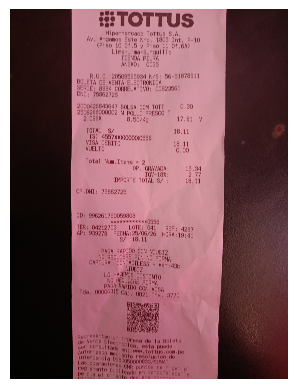

In [ ]:
# CARGA DE IMAGEN

img = None

if COLAB:
    # Modo Colab
    # Modifique el nombre y ruta de su archivo en caso 'COLAB = True' de la primera celda
    # Nombre específico de su archivo en Google Drive
    name = 'prueba0.jpg'
    # Ruta específica de su archivo en Google Drive
    ruta = f'/content/drive/MyDrive/PDS_Images/{name}'
    
    file_bytes = np.fromfile(ruta, dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    if img is not None:
        print(f"Imagen '{name}' cargada con éxito desde Google Drive.")
    else:
        print(f"Error: No se encontró la imagen en la ruta:\n{ruta}")

else:
    # Modo local

    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    ruta = filedialog.askopenfilename(
        title="Selecciona la imagen del recibo/factura",
        filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.tiff")]
    )
    root.destroy()

    if ruta:
        file_bytes = np.fromfile(ruta, dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

        if img is not None:
            print(f"Imagen cargada con éxito desde:\n{ruta}")
            cv2_imshow(img)
        else:
            print(f"Error: no se pudo leer la imagen en:\n{ruta}")
    else:
        print("No se seleccionó ningún archivo.")

#### **Reescalado de Imagen**

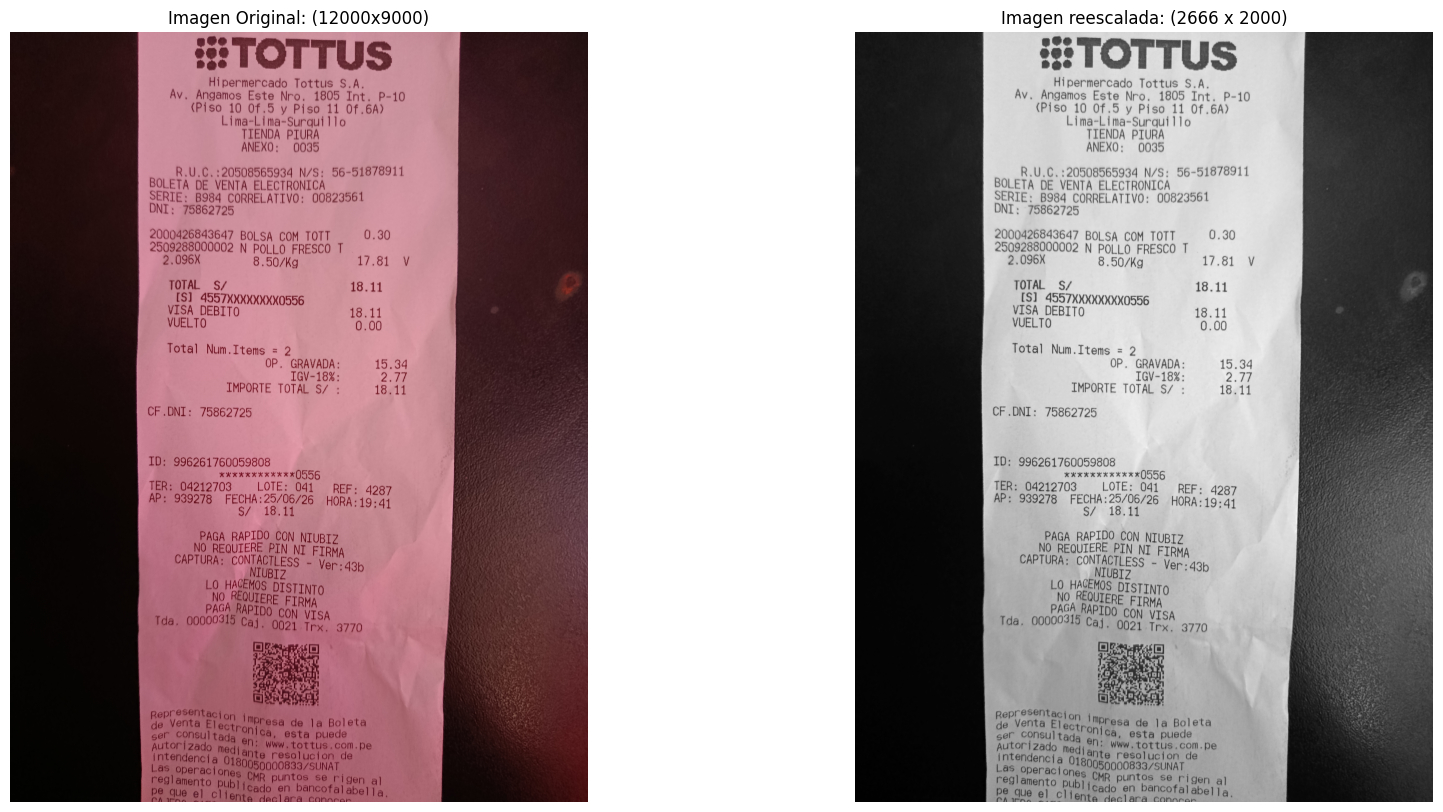

In [ ]:
# REESCALADO Y TRATAMIENTO INICIAL

if img is not None:
    # Calculo de proporciones
    ancho_des = 2000
    rows, cols, chann = img.shape
    rate = ancho_des / float(cols)
    alto_des = int(rows * rate)

    # Selección adaptativa del método de interpolación
    # INTER_AREA para reducir resolución; INTER_CUBIC para ampliar
    interpolacion = cv2.INTER_AREA if cols > ancho_des else cv2.INTER_CUBIC

    # Reescalado y conversión a escala de grises
    img_rees = cv2.resize(img, (ancho_des, alto_des), interpolation=interpolacion)
    imgG = cv2.cvtColor(img_rees, cv2.COLOR_BGR2GRAY)

    # Visualización
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.title(f"Imagen Original: ({rows}x{cols})")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Imagen reescalada: ({alto_des} x {ancho_des})")
    plt.imshow(imgG, cmap='gray')
    plt.axis('off')
    plt.show()
else:
    print("No hay ninguna imagen cargada en 'img'. Por favor ejecute la carga de su imagen primero.")

#### **Máscara Otsu para Segmentación**

Umbral calculado por Otsu: 89.0
Kernel de cierre: 100x100


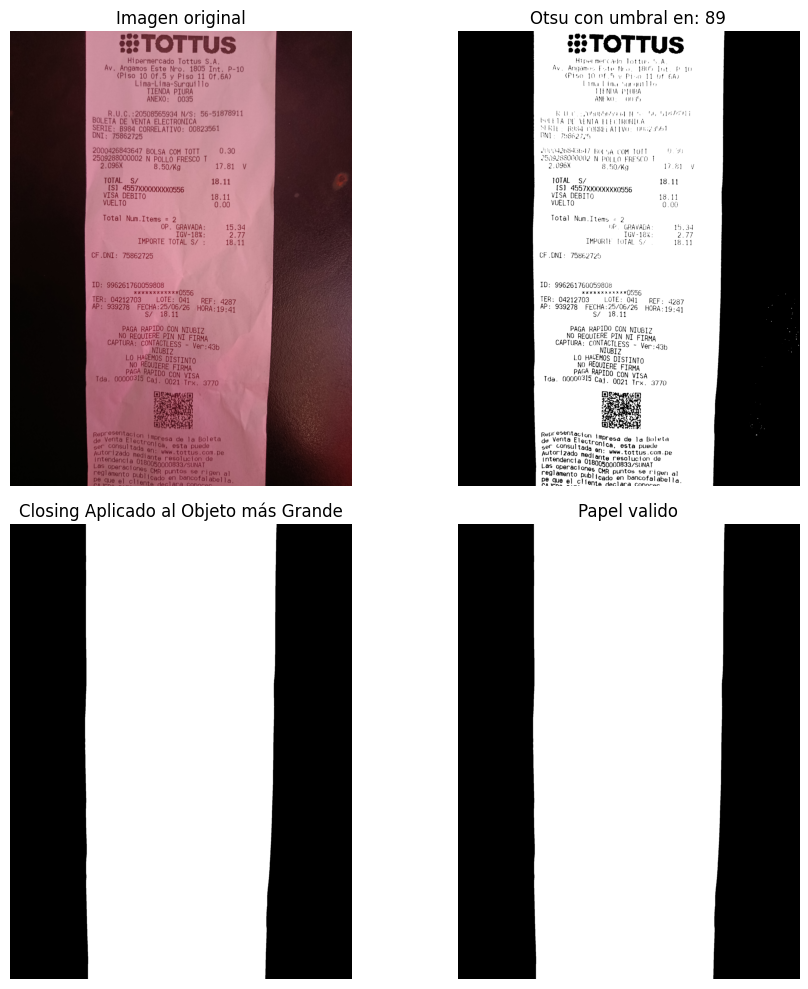

In [ ]:
# OTSU Y RELLENO INTERNO DE LA MÁSCARA

# Suavizado y Umbralización de Otsu
# El suavizado previo reduce ruido y Otsu busca de forma automática el mejor umbral de brillo para binarizar la imagen
k_blur = max(3, (round(ancho_des * 0.0025) | 1))
img_blur_otsu = cv2.GaussianBlur(imgG, (k_blur, k_blur), 0)
umbral_otsu, mascara_otsu = cv2.threshold(img_blur_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Umbral calculado por Otsu: {umbral_otsu:.1f}")

# Extracción del componente conectado más grande para descartar artefactos más pequeños y aislados
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara_otsu, connectivity=8)

if n_labels > 1:
    idx_mayor = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mascara_papel = np.uint8(labels == idx_mayor) * 255
else:
    mascara_papel = mascara_otsu.copy()

# Cierre morfológico para cerrar grietas del borde que podrían dejar el contorno fragmentado
k_closing = max(5, round(ancho_des * 0.05))

print(f"Kernel de cierre: {k_closing}x{k_closing}")

kernel_closing = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_closing, k_closing))
mascara_papel = cv2.morphologyEx(mascara_papel, cv2.MORPH_CLOSE, kernel_closing, iterations=1)

#  Relleno interno que toma el contorno EXTERIOR del papel ya tratado, y se rellena por completo hacia adentro.
contornos, _ = cv2.findContours(mascara_papel, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contornos:
    contorno_mayor = max(contornos, key=cv2.contourArea)
    mascara_papel_final = np.zeros_like(mascara_papel)
    cv2.drawContours(mascara_papel_final, [contorno_mayor], -1, 255, thickness=cv2.FILLED)
else:
    print("No se detectaron contornos válidos tras Otsu.")
    mascara_papel_final = mascara_papel.copy()

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("Imagen original")
plt.imshow(cv2.cvtColor(img_rees, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Otsu con umbral en: {umbral_otsu:.0f}")
plt.imshow(mascara_otsu, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title(f"Closing Aplicado al Objeto más Grande")
plt.imshow(mascara_papel, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Papel valido")
plt.imshow(mascara_papel_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### **Detección de Bordes y Morfología para Rotación**

Kernel de suavizado: 5x5
Kernel de dilatación: 3x30
Ángulo de rotación calculado por Transformada de Hough: 1.00 grados


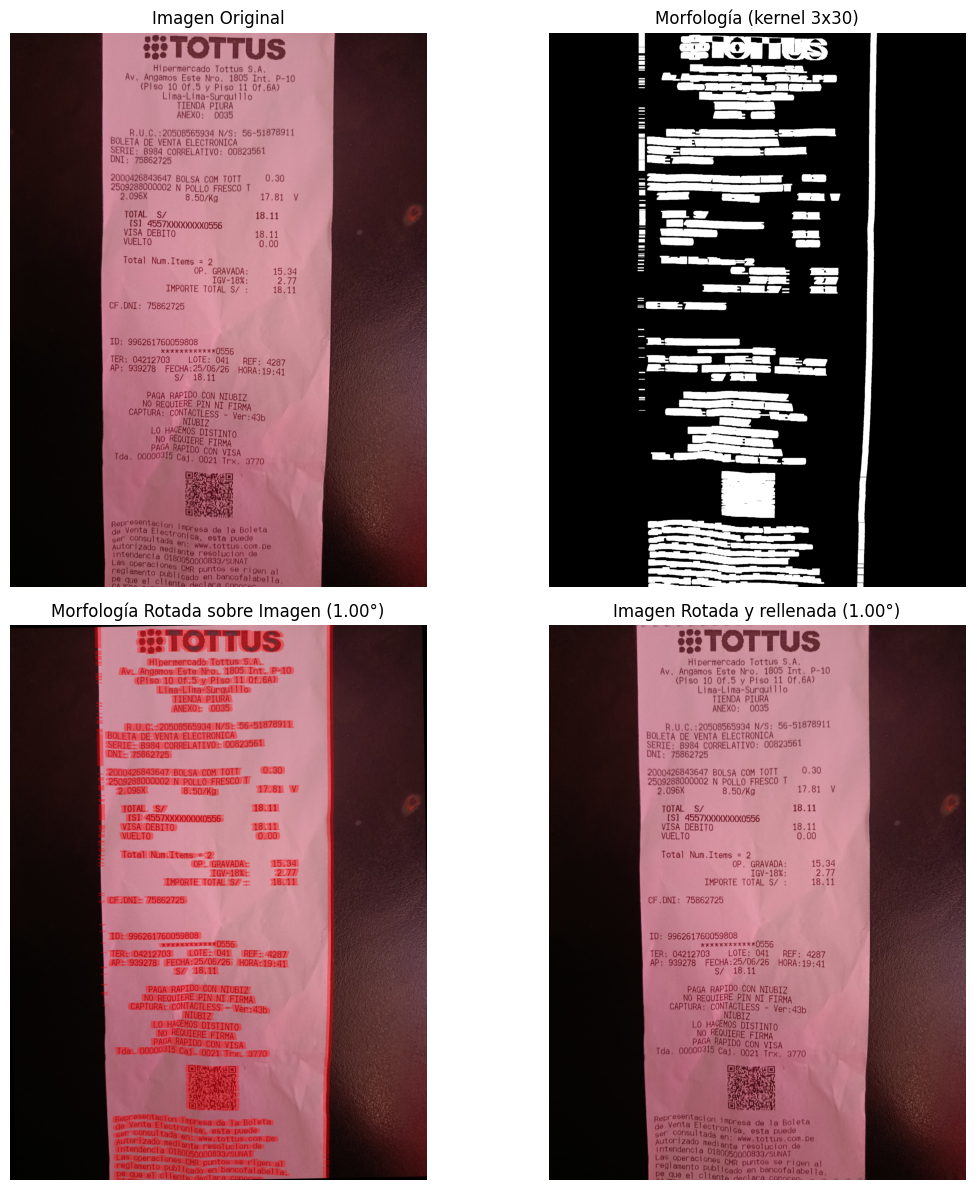

In [ ]:
# DETECCIÓN DE BORDES, MORFOLOGÍA Y CORRECCIÓN DE ROTACIÓN

# Para la detección de bordes dentro de nuestra primera máscara
img_blur = cv2.GaussianBlur(imgG, (k_blur, k_blur), 0)
img_canny_gauss = cv2.Canny(img_blur, 50, 150)
img_canny_gauss = cv2.bitwise_and(img_canny_gauss, img_canny_gauss, mask=mascara_papel_final)

# Dilatación estructural
k_ancho = max(5, round(ancho_des * 0.015))
k_alto = max(1, round(alto_des * 0.001))
estructure = np.ones((k_alto, k_ancho), np.uint8)
morfo_canny_gauss = cv2.dilate(img_canny_gauss, estructure, iterations=1)

print(f"Kernel de suavizado: {k_blur}x{k_blur}")
print(f"Kernel de dilatación: {k_alto}x{k_ancho}")

# Estimación del ángulo dominante (Hough + mediana ponderada por longitud)
rows, cols = imgG.shape

lineas = cv2.HoughLinesP(morfo_canny_gauss, rho=1, theta=np.pi / 180, threshold=50, minLineLength=30, maxLineGap=20)

angulos_detectados = []
pesos_angulos = []

if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        dx, dy = x2 - x1, y2 - y1
        longitud = np.sqrt(dx**2 + dy**2)

        angulo_deg = np.degrees(np.arctan2(dy, dx))

        # Normalización para que orientaciones equivalentes no se traten como distintas
        if angulo_deg > 90:
            angulo_deg -= 180
        elif angulo_deg < -90:
            angulo_deg += 180

        # Solo segmentos aproximadamente horizontales influyen en la estimación
        if -35 < angulo_deg < 35:
            angulos_detectados.append(angulo_deg)
            pesos_angulos.append(longitud)

if angulos_detectados:
    angulos_detectados = np.array(angulos_detectados)
    pesos_angulos = np.array(pesos_angulos)

    indices_ordenados = np.argsort(angulos_detectados)
    angulos_ordenados = angulos_detectados[indices_ordenados]
    pesos_ordenados = pesos_angulos[indices_ordenados]

    suma_pesos = np.sum(pesos_ordenados)
    peso_acumulado = np.cumsum(pesos_ordenados)
    indice_mediana = np.searchsorted(peso_acumulado, suma_pesos / 2)
    theta_optimo = angulos_ordenados[indice_mediana]
else:
    theta_optimo = 0.0

print(f"Ángulo de rotación calculado por Transformada de Hough: {theta_optimo:.2f} grados")

# Rotación de todo lo que se necesitará más adelante
centro_rotacion = (cols / 2, rows / 2)
M_rotacion = cv2.getRotationMatrix2D(centro_rotacion, theta_optimo, 1.0)

# Imagen a color: conserva interpolación lineal para buena calidad visual
img_color_rotada = cv2.warpAffine(img_rees, M_rotacion, (cols, rows))

# MÁSCARAS BINARIAS: Usamos INTER_NEAREST + threshold para garantizar uint8 puro (0 o 255)
morfo_rotada = cv2.warpAffine(morfo_canny_gauss, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST)

mascara_papel_rotada = cv2.warpAffine(mascara_papel_final, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST)
_, mascara_papel_rotada = cv2.threshold(mascara_papel_rotada, 127, 255, cv2.THRESH_BINARY)

# Imagen rotada con morfología sobrepuesta
img_color_rotada_copy = img_color_rotada.copy()
alpha = 0.4
base_rgb = cv2.cvtColor(img_color_rotada_copy, cv2.COLOR_BGR2RGB)
capa_roja = np.zeros_like(base_rgb)
capa_roja[:, :] = (255, 0, 0)

mezcla = cv2.addWeighted(base_rgb, 1 - alpha, capa_roja, alpha, 0)

mascara_bool = morfo_rotada > 0
morfo_sobre = base_rgb.copy()
morfo_sobre[mascara_bool] = mezcla[mascara_bool]

# Relleno inteligente
mascara_valida = np.full((rows, cols), 255, dtype=np.uint8)
mascara_valida = cv2.warpAffine(mascara_valida, M_rotacion, (cols, rows), flags=cv2.INTER_NEAREST, borderValue=0)

# Invertimos: ahora el blanco marca justo las zonas a rellenar
mascara_huecos = cv2.bitwise_not(mascara_valida)

img_color_rotada = cv2.inpaint(img_color_rotada, mascara_huecos, inpaintRadius=7, flags=cv2.INPAINT_TELEA)

# Visualización
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(img_rees, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Morfología (kernel {k_alto}x{k_ancho})")
plt.imshow(morfo_canny_gauss, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title(f"Morfología Rotada sobre Imagen ({theta_optimo:.2f}°)")
plt.imshow(morfo_sobre)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Imagen Rotada y rellenada ({theta_optimo:.2f}°)")
plt.imshow(cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

#### **Rescate de Elemento**

Intento Otsu - Cobertura: 100.0% -> ACEPTADO


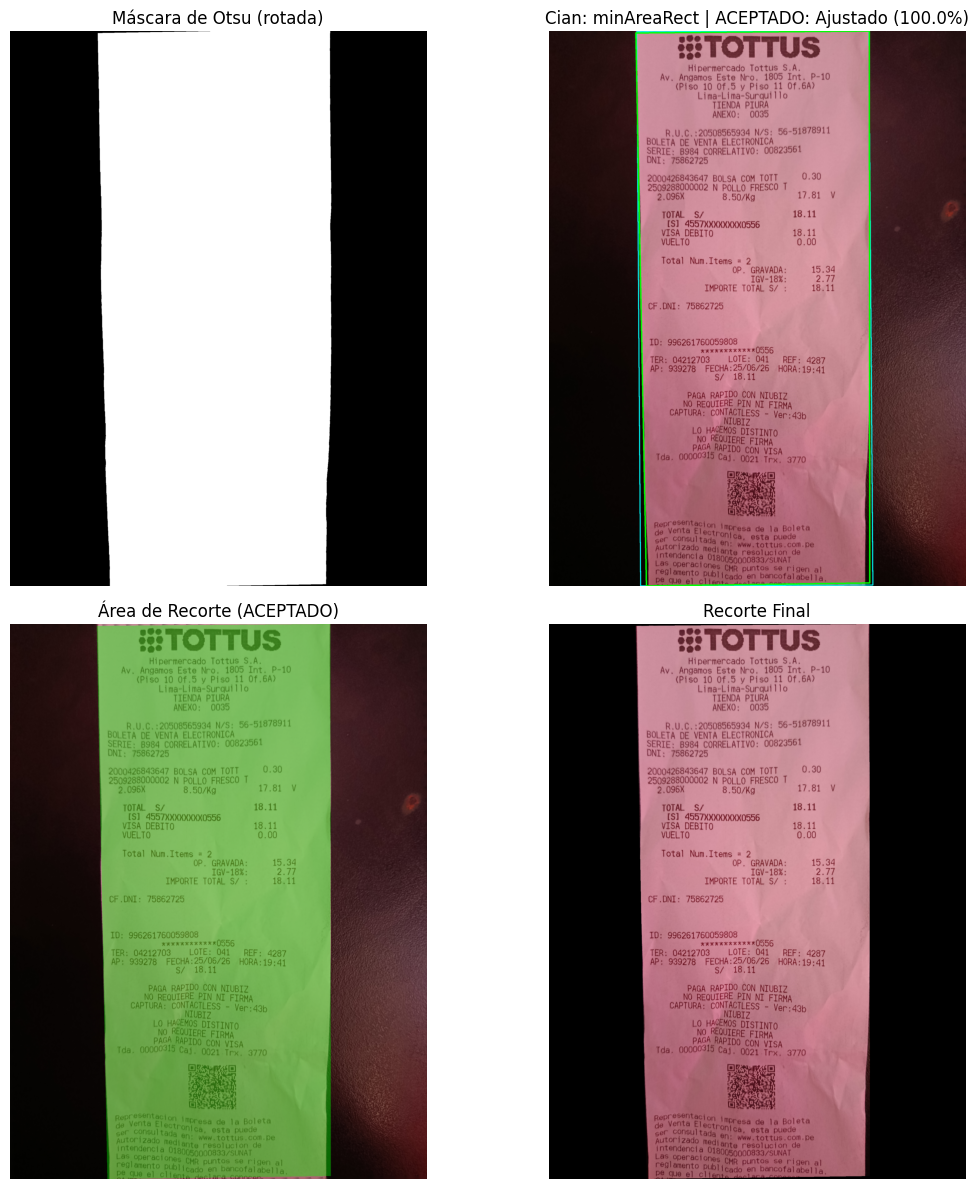

In [ ]:
# Parámetros de control 
N_ITERACIONES = 10
MARGEN_ANGULO_LADO = 10
MARGEN_ROTACION_INICIAL = 10
MARGEN_SIMILITUD = 70
MARGEN_DISTANCIA = max(3, round(ancho_des * 0.02))
PASO_MUESTREO = max(2, round(ancho_des * 0.002))
ALPHA_OVERLAY = 0.4

# Funciones geométricas y de procesamiento 
def distancia_punto_a_segmento(p, a, b):
    ab, ap = b - a, p - a
    t = np.clip(np.dot(ap, ab) / (np.dot(ab, ab) + 1e-9), 0, 1)
    return np.linalg.norm(p - (a + t * ab))

def interseccion_rectas(p1, d1, p2, d2):
    A = np.array([d1, -d2]).T
    if abs(np.linalg.det(A)) < 1e-9: return None
    return p1 + np.linalg.solve(A, p2 - p1)[0] * d1

def diferencia_angular(a1, a2):
    return abs(((a1 - a2 + 90) % 180) - 90)

def muestrear_perimetro(puntos, paso_px):
    muestras = []
    for i in range(4):
        p1, p2 = puntos[i], puntos[(i + 1) % 4]
        n_pasos = max(2, int(np.linalg.norm(p2 - p1) // paso_px))
        muestras.extend([p1 + t * (p2 - p1) for t in np.linspace(0, 1, n_pasos, endpoint=False)])
    return np.array(muestras)

def ajustar_y_validar_cuadrilatero(mascara_entrada, ancho_img, alto_img):
    contornos, _ = cv2.findContours(mascara_entrada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos: return False, 0.0, None, None, np.zeros_like(mascara_entrada)
    contorno_mayor = max(contornos, key=cv2.contourArea)
    puntos_hull = cv2.convexHull(contorno_mayor).reshape(-1, 2).astype(np.float64)
    rect_inicial = cv2.minAreaRect(contorno_mayor)
    vertices_iniciales = cv2.boxPoints(rect_inicial).astype(np.float64)
    caja_inicial = np.clip(vertices_iniciales, [0, 0], [ancho_img - 1, alto_img - 1]).astype(np.int32)
    angulo_rect = rect_inicial[2]
    angulo_inicial = abs(90 - abs(angulo_rect)) if abs(angulo_rect) > 45 else abs(angulo_rect)
    if angulo_inicial > MARGEN_ROTACION_INICIAL: return False, 0.0, None, caja_inicial, np.zeros_like(mascara_entrada)
    vertices = vertices_iniciales.copy()
    angulos_originales = [np.degrees(np.arctan2(*(vertices[(i + 1) % 4] - vertices[i])[::-1])) for i in range(4)]
    for _ in range(N_ITERACIONES):
        asignaciones = np.array([np.argmin([distancia_punto_a_segmento(p, vertices[i], vertices[(i + 1) % 4]) for i in range(4)]) for p in puntos_hull])
        lineas_ajustadas = []
        for i in range(4):
            puntos_lado = puntos_hull[asignaciones == i]
            a_actual, b_actual = vertices[i], vertices[(i + 1) % 4]
            d_actual = (b_actual - a_actual) / (np.linalg.norm(b_actual - a_actual) + 1e-9)
            if len(puntos_lado) >= 2:
                vx, vy, x0, y0 = cv2.fitLine(puntos_lado.astype(np.float32), cv2.DIST_L2, 0, 0.01, 0.01).flatten()
                desvio = diferencia_angular(np.degrees(np.arctan2(vy, vx)), angulos_originales[i])
                lineas_ajustadas.append((np.array([x0, y0]), np.array([vx, vy])) if desvio <= MARGEN_ANGULO_LADO else (a_actual, d_actual))
            else:
                lineas_ajustadas.append((a_actual, d_actual))
        nuevas_vertices = []
        for i in range(4):
            p_prev, d_prev = lineas_ajustadas[(i - 1) % 4]
            p_act, d_act = lineas_ajustadas[i]
            interseccion = interseccion_rectas(p_prev, d_prev, p_act, d_act)
            nuevas_vertices.append(interseccion if interseccion is not None else vertices[i])
        vertices = np.array(nuevas_vertices)
    cuadrilatero_final = vertices.astype(np.float32)
    puntos_perimetro = muestrear_perimetro(cuadrilatero_final, PASO_MUESTREO)
    distancias_cobertura = np.array([abs(cv2.pointPolygonTest(contorno_mayor, (float(p[0]), float(p[1])), True)) for p in puntos_perimetro])
    cobertura = np.mean(distancias_cobertura <= MARGEN_DISTANCIA) * 100
    valido = cobertura >= MARGEN_SIMILITUD
    cuadrilatero_dibujo = np.clip(cuadrilatero_final, [0, 0], [ancho_img - 1, alto_img - 1]).astype(np.int32)
    mascara_cuad = np.zeros_like(mascara_entrada)
    cv2.fillPoly(mascara_cuad, [cuadrilatero_dibujo], 255)
    return valido, cobertura, cuadrilatero_dibujo, caja_inicial, mascara_cuad

# Preparación 
alto_img, ancho_img = mascara_papel_rotada.shape
base_rgb = cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2RGB)


# CADENA ENCASETADA: OTSU -> K-MEANS -> OTSU ROTADA ORIGINAL

valido, cobertura_perimetro, cuadrilatero_dibujo, caja_inicial_dibujo, mascara_cuadrilatero = ajustar_y_validar_cuadrilatero(mascara_papel_rotada, ancho_img, alto_img)
print(f"Intento Otsu - Cobertura: {cobertura_perimetro:.1f}% -> {'ACEPTADO' if valido else 'RECHAZADO'}")

if not valido:
    print("Otsu rechazado. Ejecutando K-Means (K=3) en LAB y análisis encadenado...")
    img_lab_rotada = cv2.cvtColor(img_color_rotada, cv2.COLOR_BGR2LAB)
    ys, xs = np.where(mascara_papel_rotada > 0)
    if len(ys) > 0:
        datos_ab = np.float32(img_lab_rotada[ys, xs, 1:3])
        criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        cv2.setRNGSeed(42)
        _, etiquetas, _ = cv2.kmeans(datos_ab, 3, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
        etiquetas = etiquetas.ravel()
        pixeles_morfologicos = morfo_canny_gauss[ys, xs] > 0
        conteo_morfologia = np.array([np.sum((etiquetas == i) & pixeles_morfologicos) for i in range(3)])
        orden_morfologia = np.argsort(-conteo_morfologia)
        top1, top2 = orden_morfologia[0], orden_morfologia[1]
        ratio_top2 = conteo_morfologia[top2] / (conteo_morfologia[top1] + 1e-9)
        clusters_validos = [top1, top2] if ratio_top2 >= 0.20 else [top1]
        
        mascara_boleta_filtrada = np.zeros_like(mascara_papel_rotada, dtype=np.uint8)
        for c in clusters_validos:
            sel = etiquetas == c
            mascara_boleta_filtrada[ys[sel], xs[sel]] = 255
            
        val_k, cob_k, cuad_k, caja_k, masc_k = ajustar_y_validar_cuadrilatero(mascara_boleta_filtrada, ancho_img, alto_img)
        print(f"Intento K-Means - Cobertura: {cob_k:.1f}% -> {'ACEPTADO' if val_k else 'RECHAZADO'}")
        
        if val_k:
            valido, cobertura_perimetro, cuadrilatero_dibujo, caja_inicial_dibujo, mascara_cuadrilatero = val_k, cob_k, cuad_k, caja_k, masc_k
            print("Resultado validado exitosamente mediante K-Means.")
        else:
            print("K-Means también fue rechazado. Se adopta por defecto el Otsu rotado original.")

# Selección Final y Visualización 
mascara_seleccion_final = mascara_cuadrilatero if valido else mascara_papel_rotada
img_recorte_final = cv2.bitwise_and(img_color_rotada, img_color_rotada, mask=mascara_seleccion_final)
color_estado = (0, 255, 0) if valido else (255, 0, 0)

img_debug = base_rgb.copy()
if caja_inicial_dibujo is not None: cv2.drawContours(img_debug, [caja_inicial_dibujo], -1, (0, 255, 255), 4)
if cuadrilatero_dibujo is not None: cv2.drawContours(img_debug, [cuadrilatero_dibujo], -1, color_estado, 5)

capa_color = np.full_like(base_rgb, color_estado, dtype=np.uint8)
mezcla = cv2.addWeighted(base_rgb, 1 - ALPHA_OVERLAY, capa_color, ALPHA_OVERLAY, 0)
area_tenida = base_rgb.copy()
area_tenida[mascara_cuadrilatero > 0] = mezcla[mascara_cuadrilatero > 0]

estado = "ACEPTADO" if valido else "RECHAZADO"
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1); plt.title("Máscara de Otsu (rotada)"); plt.imshow(mascara_papel_rotada, cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 2); plt.title(f"Cian: minAreaRect | {estado}: Ajustado ({cobertura_perimetro:.1f}%)"); plt.imshow(img_debug); plt.axis('off')
plt.subplot(2, 2, 3); plt.title(f"Área de Recorte ({estado})"); plt.imshow(area_tenida); plt.axis('off')
plt.subplot(2, 2, 4); plt.title("Recorte Final"); plt.imshow(cv2.cvtColor(img_recorte_final, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.tight_layout()
plt.show()

#### **Morfología Final**

Filtro aprobado: Recortando en función al rectángulo delimitador del perímetro detectado...


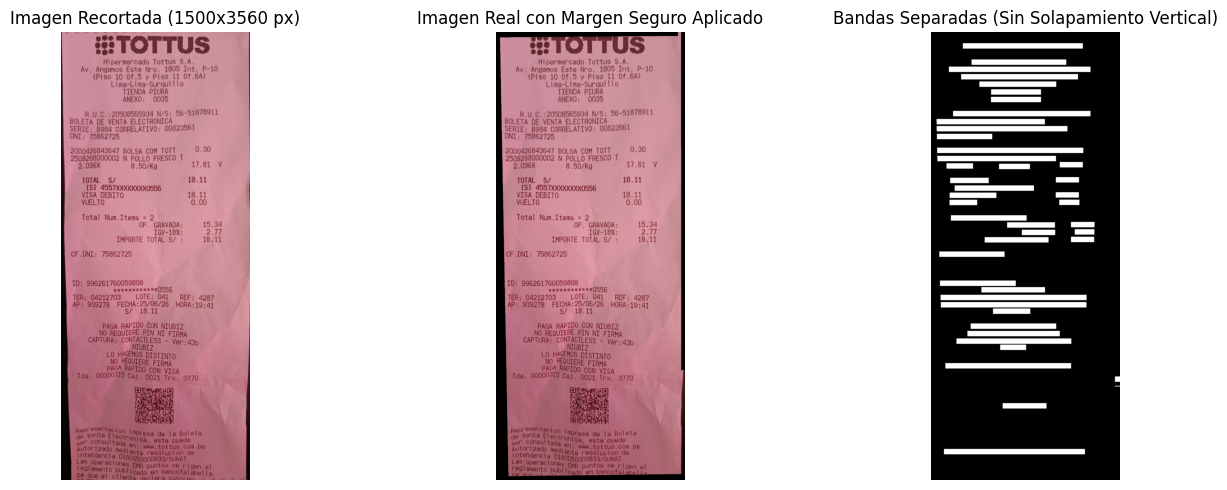

[Proceso Exitoso] Bandas de texto separadas, unidas horizontalmente y limitadas en altura (1500x3560 px).


In [ ]:
# BLOQUE DE RECORTE CONDICIONAL, REESCALADO Y MORFOLOGÍA AVANZADA DE LÍNEAS

# 1. EVALUAR SI SE USÓ EL FILTRO DE PERÍMETRO O EL FALLBACK DE OTSU
if valido and cuadrilatero_dibujo is not None:
    print("Filtro aprobado: Recortando en función al rectángulo delimitador del perímetro detectado...")
    x, y, w, h = cv2.boundingRect(cuadrilatero_dibujo)
    img_base_trabajo = img_color_rotada[y:y+h, x:x+w].copy()
    mascara_base_trabajo = mascara_seleccion_final[y:y+h, x:x+w].copy()
    morfo_base_trabajo = morfo_rotada[y:y+h, x:x+w].copy()
else:
    print("Fallback activo (Otsu arrastrado): Tomando la capa y máscara completa sin recorte previo...")
    img_base_trabajo = img_color_rotada.copy()
    mascara_base_trabajo = mascara_papel_rotada.copy()
    morfo_base_trabajo = morfo_rotada.copy()

# 2. REESCALAR AL 75% DEL ANCHO DESEADO CON ALTO PROPORCIONAL
h_orig, w_orig = img_base_trabajo.shape[:2]
nuevo_ancho = int(ancho_des * 0.75)

proporcion = nuevo_ancho / float(w_orig)
nuevo_alto = int(h_orig * proporcion)

interpolacion_img = cv2.INTER_AREA if w_orig > nuevo_ancho else cv2.INTER_CUBIC

img_trabajo = cv2.resize(img_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=interpolacion_img)
mascara_trabajo = cv2.resize(mascara_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_NEAREST)
morfo_trabajo = cv2.resize(morfo_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_NEAREST)

ancho_trabajo_des = nuevo_ancho
alto_trabajo_des = nuevo_alto

# 3. APLICAR EROSIÓN EN LOS BORDES DE LA MÁSCARA PARA DESCARTAR RESIDUOS PERIFÉRICOS
k_tamano_erosion = max(2, round(ancho_trabajo_des * 0.04))
kernel_erosion = np.ones((k_tamano_erosion, k_tamano_erosion), np.uint8)
mascara_erosionada = cv2.erode(mascara_trabajo, kernel_erosion, iterations=1)

img_real_con_margen = cv2.bitwise_and(img_trabajo, img_trabajo, mask=mascara_erosionada)
morfo_dentro_de_mascara = cv2.bitwise_and(morfo_trabajo, morfo_trabajo, mask=mascara_erosionada)

# 4. SEPARACIÓN VERTICAL FUERTE (Erosión/Apertura agresiva para separar bandas de texto)
k_sep_alto = max(5, round(alto_trabajo_des * 0.02))
kernel_separacion_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (k_sep_alto, 1))
morfo_separada_vertical = cv2.morphologyEx(morfo_dentro_de_mascara, cv2.MORPH_OPEN, kernel_separacion_vertical)

# 5. MORFOLOGÍA HORIZONTAL AMPLIA (Elemento estructural rectangular y horizontal)
k_h_ancho = max(25, round(ancho_trabajo_des * 0.08))
k_h_alto = max(1, round(alto_trabajo_des * 0.001))
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (k_h_ancho, k_h_alto))
morfo_unida_horizontal = cv2.morphologyEx(morfo_separada_vertical, cv2.MORPH_CLOSE, kernel_horizontal)

# 6. ESTANDARIZACIÓN DE ALTURA Y PREVENCIÓN DE CONTACTO VERTICAL (Componentes Conectados)
mascara_final_unida = np.zeros_like(morfo_unida_horizontal, dtype=np.uint8)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(morfo_unida_horizontal, connectivity=8)

# Altura estándar máxima permitida para una línea de texto basada en la altura del recorte
max_altura_estandar = max(12, int(alto_trabajo_des * 0.012))

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area < 30:  # Ignorar ruido pequeño
        continue
    
    x_comp = stats[i, cv2.CC_STAT_LEFT]
    y_comp = stats[i, cv2.CC_STAT_TOP]
    w_comp = stats[i, cv2.CC_STAT_WIDTH]
    h_comp = stats[i, cv2.CC_STAT_HEIGHT]
    
    # Limitar la altura de cada elemento para que no supere la altura estándar y evitar solapamientos
    if h_comp > max_altura_estandar:
        diferencia = h_comp - max_altura_estandar
        y_comp += diferencia // 2
        h_comp = max_altura_estandar
        
    # Estampar la banda controlada en la máscara final sin permitir contacto vertical
    cv2.rectangle(mascara_final_unida, (x_comp, y_comp), (x_comp + w_comp, y_comp + h_comp), 255, -1)

# Asegurar que se respete estrictamente la máscara erosionada principal
mascara_final_unida = cv2.bitwise_and(mascara_final_unida, mascara_final_unida, mask=mascara_erosionada)

# 7. VISUALIZACIÓN DE LOS RESULTADOS
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Imagen Recortada ({nuevo_ancho}x{nuevo_alto} px)")
plt.imshow(cv2.cvtColor(img_trabajo, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Imagen Real con Margen Seguro Aplicado")
plt.imshow(cv2.cvtColor(img_real_con_margen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Bandas Separadas (Sin Solapamiento Vertical)")
plt.imshow(mascara_final_unida, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"[Proceso Exitoso] Bandas de texto separadas, unidas horizontalmente y limitadas en altura ({nuevo_ancho}x{nuevo_alto} px).")

### **Selección de Texto y Almacenamiento de Recortes**

Total de contornos geométricos detectados: 45
Líneas de texto reales encuadradas con éxito: 44



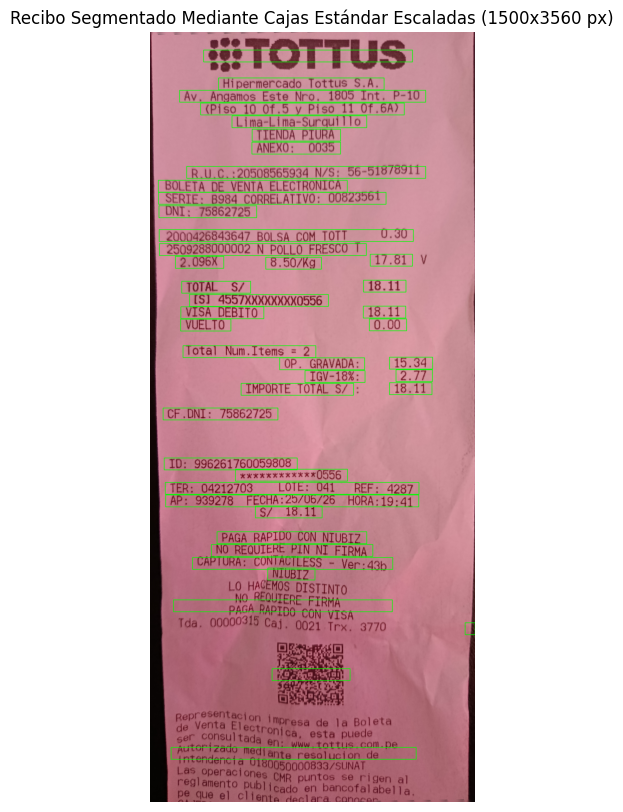

In [ ]:
# BLOQUE DE LOCALIZACIÓN Y EXTRACCIÓN DE CAJAS DE TEXTO (MEDIDAS ESTANDARIZADAS Y ESCALADAS)

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# 1. Clonar la imagen de trabajo actual (reducida al 75%) para el lienzo de dibujo
img_segmentada_geo = img_trabajo.copy()

# 2. Detección de fronteras externas utilizando nuestra máscara binaria final unida y separada
contornos_estabilizados, _ = cv2.findContours(mascara_final_unida, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 3. Extraer dimensiones dinámicas de la matriz de trabajo actual
alto_total, ancho_total = mascara_final_unida.shape[:2]

# Control de Bloques adaptados proporcionalmente al nuevo tamaño
margen_x = max(2, round(8 * factor_escala))  # Margen horizontal escalado
margen_y = max(2, round(8 * factor_escala))  # Margen vertical escalado

# Límites mínimos de tamaño adaptados (originalmente 14 píxeles para el diseño base de 2000px)
min_h_adaptativo = max(8, round(14 * factor_escala))
min_w_adaptativo = max(8, round(14 * factor_escala))

# Creamos listas de almacenamiento
cajas_validas = []
contador_cajas_geo = 0

for c in contornos_estabilizados:
    # Obtener coordenadas de la caja delimitadora alineada a los ejes cartesianos
    x, y, w, h = cv2.boundingRect(c)
    
    # Calcular la relación de aspecto
    aspect_ratio = w / float(h)
    
    # El alto de la caja debe estar dentro del rango adaptativo y menor al 5% del alto total
    es_altura_valida = (min_h_adaptativo < h < (alto_total * 0.05))
    
    # El ancho debe estar dentro del rango adaptativo y menor al 90% del ancho total
    es_ancho_valido = (min_w_adaptativo < w < (ancho_total * 0.90))
    
    # Las estructuras de texto horizontal poseen un ancho mayor o comparable a su altura
    es_proporcion_texto = (aspect_ratio > 0.7)
    
    # Condicional de aprobación estructural
    if es_altura_valida and es_ancho_valido and es_proporcion_texto:
        
        # Evita que el recorte empiece fuera de la imagen
        x_transformado = max(0, x - margen_x)
        y_transformado = max(0, y - margen_y)
        
        # Evita que el ancho o alto extendido superen los bordes máximos de la imagen
        w_transformado = min(ancho_total - x_transformado, w + (2 * margen_x))
        h_transformado = min(alto_total - y_transformado, h + (2 * margen_y))
        
        # Dibujar rectángulos usando las coordenadas escaladas sobre el lienzo de trabajo
        cv2.rectangle(img_segmentada_geo, 
                      (x_transformado, y_transformado), 
                      (x_transformado + w_transformado, y_transformado + h_transformado), 
                      (0, 255, 0), 2)
        
        contador_cajas_geo += 1

        # Almacenar las coordenadas transformadas para que el bloque de OCR herede exactamente el nuevo tamaño
        cajas_validas.append((x_transformado, y_transformado, w_transformado, h_transformado))

print(f"Total de contornos geométricos detectados: {len(contornos_estabilizados)}")
print(f"Líneas de texto reales encuadradas con éxito: {contador_cajas_geo}\n")


# VISUALIZACIÓN DEL RESULTADO GEOMÉTRICO

plt.figure(figsize=(8, 10))
plt.title(f"Recibo Segmentado Mediante Cajas Estándar Escaladas ({nuevo_ancho}x{nuevo_alto} px)")
plt.imshow(cv2.cvtColor(img_segmentada_geo, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### **Alineación de Recortes y Binarización**

Estructura final optimizada: 36 filas listas para OCR.


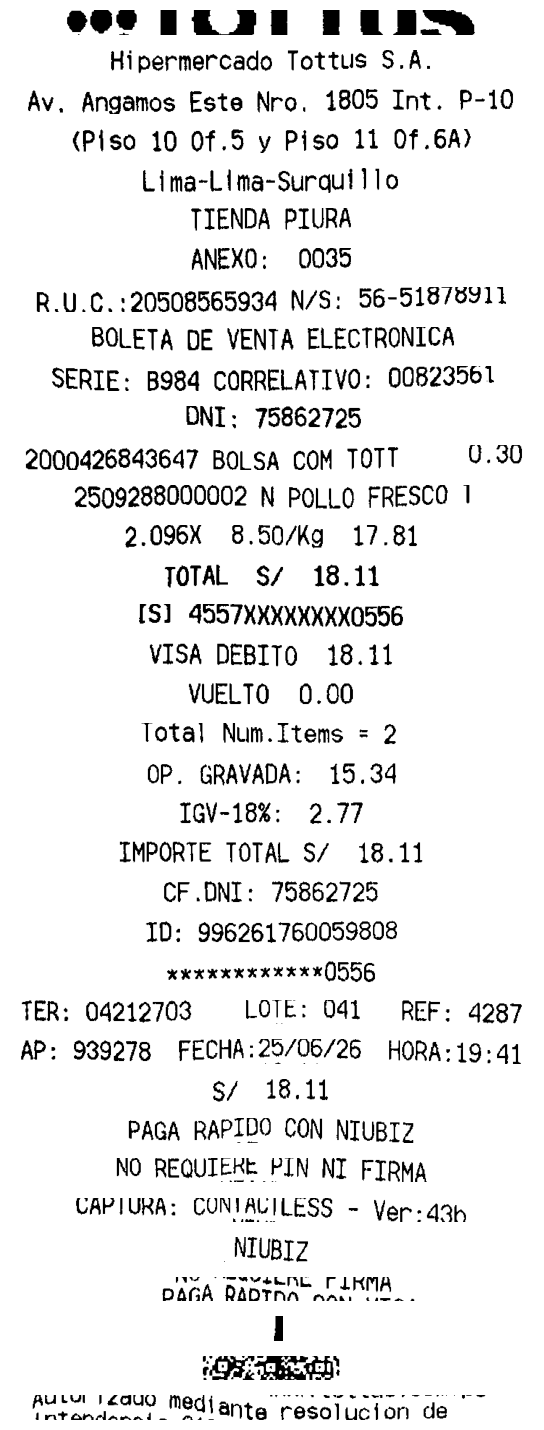

In [ ]:
# BLOQUE DE AGRUPAMIENTO POR FILAS, EXTRACCIÓN Y NORMALIZACIÓN PARA OCR

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# 1. Calcular centroides verticales y ordenar de arriba a abajo en un solo paso
bloques = sorted([(x, y, w, h, y + h//2) for (x, y, w, h) in cajas_validas], key=lambda b: b[4])

# 2. Agrupamiento dinámico por filas según margen de tolerancia adaptado
filas_estructuradas = []
if bloques:
    fila_actual = [bloques[0]]
    # Tolerancia vertical adaptada proporcionalmente al nuevo tamaño
    tolerancia_y = max(8, round(28 * factor_escala)) 
    
    for b in bloques[1:]:
        if abs(b[4] - fila_actual[0][4]) <= tolerancia_y:
            fila_actual.append(b)
        else:
            filas_estructuradas.append(sorted(fila_actual, key=lambda item: item[0]))
            fila_actual = [b]
    filas_estructuradas.append(sorted(fila_actual, key=lambda item: item[0]))

# 3. Extracción, Escalado y Binarización
recortes_ocr_por_fila = []
tiras_visuales_filas = []

# Parámetros de normalización escalados
ALTO_TARGET = max(20, round(45 * factor_escala))
UMBRAL_GROSOR = 127  # Valor neutro / binarización

for fila in filas_estructuradas:
    rois_binarias_fila = []
    
    for (x, y, w, h, _) in fila:
        # Segmento extraído de la imagen de trabajo actual (ya recortada y reescalada al 75%)
        roi = img_trabajo[y:y+h, x:x+w]
        
        # Validar que el ROI no tenga dimensiones vacías
        if roi.size == 0:
            continue
            
        # Extracción de Luminancia en CIELAB
        roi_L = cv2.cvtColor(roi, cv2.COLOR_BGR2Lab)[:, :, 0]
        
        # Segmentación Óptima de Otsu
        _, roi_bin = cv2.threshold(roi_L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Escalado Proporcional Adaptativo
        ancho_proporcional = max(5, int(w * (ALTO_TARGET / max(1, h))))
        roi_escalada = cv2.resize(roi_bin, (ancho_proporcional, ALTO_TARGET), interpolation=cv2.INTER_CUBIC)
        
        # Re-binarización Final
        _, roi_final = cv2.threshold(roi_escalada, UMBRAL_GROSOR, 255, cv2.THRESH_BINARY)
        
        # Guardamos la matriz normalizada para el OCR
        rois_binarias_fila.append(roi_final)
        
    if rois_binarias_fila:
        recortes_ocr_por_fila.append(rois_binarias_fila)
        
        # Concatenar horizontalmente los bloques para el reporte visual (separador adaptado)
        ancho_separador = max(4, round(14 * factor_escala))
        separador_blanco = np.ones((ALTO_TARGET, ancho_separador), dtype=np.uint8) * 255
        
        fila_unida = rois_binarias_fila[0]
        for r in rois_binarias_fila[1:]:
            fila_unida = np.hstack((fila_unida, separador_blanco, r))
        
        tiras_visuales_filas.append(fila_unida)

print(f"Estructura final optimizada: {len(recortes_ocr_por_fila)} filas listas para OCR.")


# RENDERIZADO DEL REPORTE VISUAL DE FILAS

if tiras_visuales_filas:
    num_filas = len(tiras_visuales_filas)
    plt.figure(figsize=(8, max(2, num_filas * 0.4))) 

    for idx, tira in enumerate(tiras_visuales_filas):
        plt.subplot(num_filas, 1, idx + 1)
        plt.imshow(tira, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron filas válidas para visualizar.")

### **Filtro de Variables o Palabras Claves**

Iniciando Lectura OCR sobre imágenes normalizadas...
[Fila 00]: TLLAR AREO
[Fila 01]: Hipermercado Tottus S.A.
[Fila 02]: Av. Angamos Este Nro, 1805 Int. P-10
[Fila 03]: (Piso 10 0f.5 y Piso 11 Of.6A)
[Fila 04]: Lima-Lima-Surquillo
[Fila 05]: TIENDA PIURA
[Fila 06]: ANEXO: — 0035
[Fila 07]: R.U.C. :20508565934 N/S: 56-518/8911
[Fila 08]: BOLETA DE VENTA ELECTRONICA
[Fila 09]: SERIE: B984 CORRELATIVO: 00823561
[Fila 10]: DNI: 75862725
[Fila 11]: 2000426843647 BOLSA COM TOTT U.30
[Fila 12]: 2509288000002 N POLLO FRESCO |
[Fila 13]: 2.096X 8.50/Kg 17.81
[Fila 14]: TOTAL $S/ 18.11
[Fila 15]: [S] 4557XXXKXXXX0556
[Fila 16]: VISA DEBITO 18.11
[Fila 17]: VUELTO 0.00
[Fila 18]: Total Num.Items = 2
[Fila 19]: OP. GRAVADA: 15.34
[Fila 20]: IGV-18%: 2.77
[Fila 21]: IMPORTE TOTAL S/ 18.11
[Fila 22]: CF.DNI: 75862725
[Fila 23]: ID: 996261760059808
[Fila 24]: E EE d $l dddO
[Fila 25]: TER: 04212703 LOTE: 041 REF: 4287
[Fila 26]: AP: 939278 FECHA:25/06/25 HORA:19:41
[Fila 27]: S/ 18.11
[Fila 28]: PAG

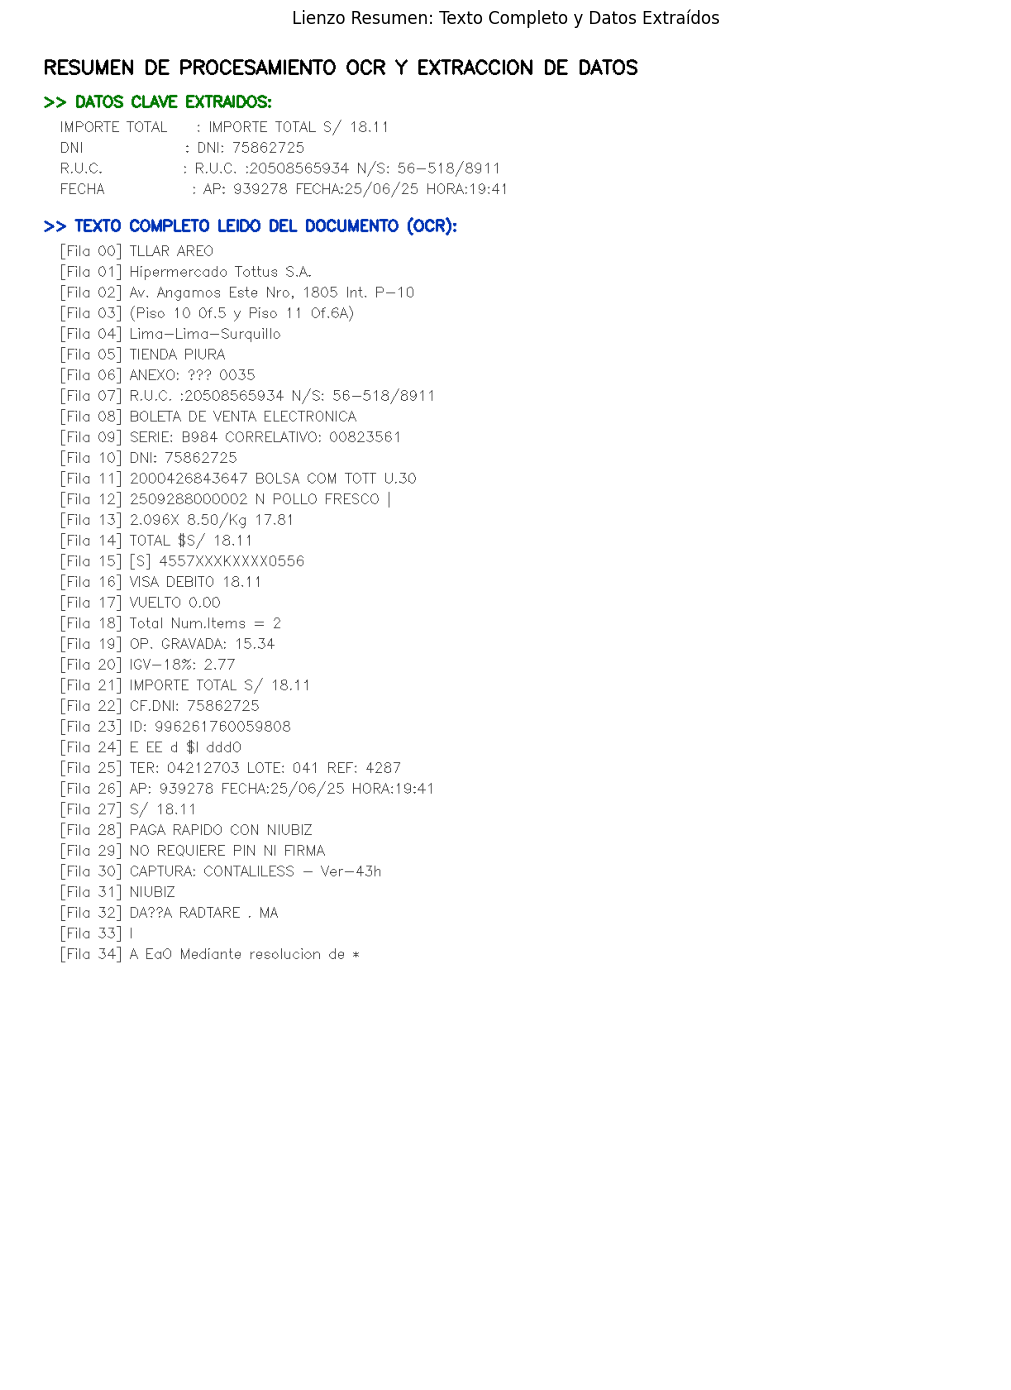

In [ ]:
# BLOQUE DE LECTURA OCR, EXTRACCIÓN DINÁMICA Y LIENZO RESUMEN

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# Margen adaptativo escalado para el OCR de Tesseract
mar = max(2, round(5 * factor_escala))

config_ocr = r'--psm 7 --oem 3 -l spa'
documento_texto = []

print("Iniciando Lectura OCR sobre imágenes normalizadas...")

for idx_f, fila_matrices in enumerate(recortes_ocr_por_fila):
    bloques_texto_fila = []
    
    for roi_bin in fila_matrices:
        roi_lista = cv2.copyMakeBorder(roi_bin, mar, mar, mar, mar, cv2.BORDER_CONSTANT, value=255)
        texto_detectado = pytesseract.image_to_string(roi_lista, config=config_ocr)
        texto_limpio = texto_detectado.strip()
        
        if texto_limpio:
            bloques_texto_fila.append(texto_limpio)
            
    if bloques_texto_fila:
        linea_final = " ".join(bloques_texto_fila)
        print(f"[Fila {idx_f:02d}]: {linea_final}")
        documento_texto.append(linea_final)

print(f"Procesamiento OCR completado con éxito.\n")


# DICCIONARIO DE CONDICIONALES DINÁMICAS

filtros_reglas = {
    "PASAJERO":                 {"tipo": "texto",   "largo": None},
    "RECIBO":                   {"tipo": "decimal", "largo": None},
    "CÓDIGO":                   {"tipo": "fijo",    "largo": None},
    "IMPORTE TOTAL":            {"tipo": "decimal", "largo": None},
    "TOTAL A PAGAR":            {"tipo": "decimal", "largo": None},
    "TOTAL RECIBO" :            {"tipo": "decimal", "largo": None},
    "TOTAL":                    {"tipo": "decimal", "largo": None},
    "IDENTIDAD":                {"tipo": "fijo",    "largo": 8},
    "DNI":                      {"tipo": "fijo",    "largo": 8},
    "RUC":                      {"tipo": "fijo",    "largo": 11},
    "RUT":                      {"tipo": "decimal", "largo": None},
    "R.U.C.":                   {"tipo": "fijo",    "largo": 11},
    "R.U.C":                    {"tipo": "fijo",    "largo": 11},
    "R.U.":                     {"tipo": "fijo",    "largo": 11},
    "ruc":                      {"tipo": "fijo",    "largo": 11},
    "FECHA DE EMISIÓN":         {"tipo": "decimal", "largo": None},
    "FECHA":                    {"tipo": "decimal", "largo": None},
    "F VIAJE":                  {"tipo": "decimal", "largo": None},
}

datos_extraidos = {}
desactivados = set()  
keywords_ordenadas = list(filtros_reglas.keys())

# MOTOR DE EVALUACIÓN POR ESCANEO GLOBAL Y DESACTIVACIÓN EN CASCADA
for idx, keyword in enumerate(keywords_ordenadas):
    if keyword in desactivados:
        continue
        
    regla = filtros_reglas[keyword]
    lineas_encontradas = []
    
    for linea in documento_texto:
        linea_upper = linea.upper()
        
        if keyword in linea_upper:
            # Validación Tipo Fijo
            if regla["tipo"] == "fijo":
                for palabra in linea.split():
                    bloque_numerico = "".join(c for c in palabra if c.isdigit())
                    if len(bloque_numerico) == regla["largo"]:
                        lineas_encontradas.append(linea)
                        break 
            
            # Validación Tipo Decimal/Variable
            elif regla["tipo"] == "decimal":
                if any(c.isdigit() for c in linea):
                    lineas_encontradas.append(linea)
            
            # Validación Tipo Texto (Acepta líneas sin números, ej. nombres)
            elif regla["tipo"] == "texto":
                lineas_encontradas.append(linea)

    if lineas_encontradas:
        if keyword not in datos_extraidos:
            datos_extraidos[keyword] = []
        datos_extraidos[keyword].extend(lineas_encontradas)
        
        for j in range(idx + 1, len(keywords_ordenadas)):
            posible_hijo = keywords_ordenadas[j]
            if posible_hijo in keyword: 
                desactivados.add(posible_hijo)


# IMPRESIÓN DE RESULTADOS EN CONSOLA

print("Información detectada:\n")
for clave, lineas in datos_extraidos.items():
    if lineas:
        print(f"{clave:<16} : {lineas[0]}")
        for l in lineas[1:]:
            print(f"{'':<16} : {l}")


# BLOQUE DE RENDERIZADO DE TEXTO EN LIENZO (IMAGEN RESUMEN)

ancho_lienzo = 1200
total_lineas_estimadas = len(documento_texto) + len(datos_extraidos) + 12
alto_lienzo = max(800, total_lineas_estimadas * 30 + 100)

lienzo_texto = np.ones((alto_lienzo, ancho_lienzo, 3), dtype=np.uint8) * 255

fuente = cv2.FONT_HERSHEY_SIMPLEX
escala_titulo = 0.75
escala_texto = 0.55
color_texto_normal = (50, 50, 50)       
color_titulo_seccion = (180, 50, 0)     
color_destacado = (0, 120, 0)           

x_margen = 40
y_actual = 50

cv2.putText(lienzo_texto, "RESUMEN DE PROCESAMIENTO OCR Y EXTRACCION DE DATOS", (x_margen, y_actual), fuente, escala_titulo, (0, 0, 0), 2)
y_actual += 40

cv2.putText(lienzo_texto, ">> DATOS CLAVE EXTRAIDOS:", (x_margen, y_actual), fuente, escala_texto + 0.05, color_destacado, 2)
y_actual += 30

if datos_extraidos:
    for clave, lineas in datos_extraidos.items():
        texto_dato = f"{clave:<16} : {lineas[0]}"
        cv2.putText(lienzo_texto, texto_dato, (x_margen + 20, y_actual), fuente, escala_texto, color_texto_normal, 1)
        y_actual += 25
else:
    cv2.putText(lienzo_texto, "(No se detectaron campos bajo las reglas especificadas)", (x_margen + 20, y_actual), fuente, escala_texto, (120, 120, 120), 1)
    y_actual += 25

y_actual += 20

cv2.putText(lienzo_texto, ">> TEXTO COMPLETO LEIDO DEL DOCUMENTO (OCR):", (x_margen, y_actual), fuente, escala_texto + 0.05, color_titulo_seccion, 2)
y_actual += 30

for idx, linea in enumerate(documento_texto):
    texto_linea = f"[Fila {idx:02d}] {linea}"
    if len(texto_linea) > 115:
        texto_linea = texto_linea[:112] + "..."
        
    cv2.putText(lienzo_texto, texto_linea, (x_margen + 20, y_actual), fuente, escala_texto, color_texto_normal, 1)
    y_actual += 25
    
    if y_actual > alto_lienzo - 40:
        cv2.putText(lienzo_texto, "... [Texto truncado por limite de altura del lienzo]", (x_margen + 20, y_actual), fuente, escala_texto, (0, 0, 255), 1)
        break

plt.figure(figsize=(12, 14))
plt.title("Lienzo Resumen: Texto Completo y Datos Extraídos")
plt.imshow(cv2.cvtColor(lienzo_texto, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()